<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/1_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial: Data Preprocessing and Exploratory Data Analysis (EDA) Using Python
**Dataset:** Embedded synthetic "Customer Churn" sample dataset (generated in-notebook, no upload needed)

## Section 1: Introduction — Objective
In this notebook, we will learn how to:
- Load data
- Understand data types
- Explore distributions
- Handle missing values
- Detect and treat outliers
- Handle noisy data
- Analyze class imbalance
- Encode categorical variables
- Scale numerical features
- Prepare data for machine learning

In [31]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
%matplotlib inline

### Create the Sample Dataset (Embedded)
Instead of uploading a file, we generate a synthetic "Customer Churn" dataset directly in the notebook.
It deliberately includes missing values, an income outlier, and class imbalance — just like the
original `data_quality_practice_dataset.xlsx` — so every technique below has something real to work on.

In [32]:
#Generate Embedded Sample Dataset
np.random.seed(42)

n = 100

customer_id = np.arange(1, n + 1)
age = np.random.randint(18, 66, size=n).astype(float)
income = np.random.normal(60000, 15000, size=n).round(0)
income = np.clip(income, 20000, 100000)
gender = np.random.choice(["M", "F"], size=n)
city = np.random.choice(["Bengaluru", "Mumbai", "Delhi", "Chennai"], size=n, p=[0.28, 0.26, 0.18, 0.28])
purchase_amount = np.random.normal(5600, 1200, size=n).round(0).astype(int)

# Churn is imbalanced: ~10% churners, and higher PurchaseAmount slightly increases churn likelihood
churn_prob = 0.05 + (purchase_amount - purchase_amount.min()) / (purchase_amount.max() - purchase_amount.min()) * 0.15
churn = np.random.binomial(1, churn_prob)

df = pd.DataFrame({
    "CustomerID": customer_id,
    "Age": age,
    "Income": income,
    "Gender": gender,
    "City": city,
    "PurchaseAmount": purchase_amount,
    "Churn": churn
})

# Inject missing values (like the original dataset)
missing_age_idx = np.random.choice(df.index, size=2, replace=False)
missing_income_idx = np.random.choice(df.index, size=3, replace=False)
df.loc[missing_age_idx, "Age"] = np.nan
df.loc[missing_income_idx, "Income"] = np.nan

# Inject a realistic outlier in Income (a data-entry style error)
outlier_idx = np.random.choice(df.index, size=1)
df.loc[outlier_idx, "Income"] = 500000.0

df.head()

,CustomerID,Age,Income,Gender,City,PurchaseAmount,Churn
0,1,56.0,68732.0,F,Bengaluru,5577,0
1,2,46.0,73316.0,M,Chennai,4481,0
2,3,32.0,73415.0,F,Chennai,4046,0
3,4,60.0,71325.0,F,Chennai,5474,0
4,5,25.0,56893.0,F,Mumbai,3206,0


In [33]:
#Dataset Overview
df.shape

(100, 7)

Questions
- How many rows?
- How many columns?

In [34]:
#Column Names
df.columns

Index(['CustomerID', 'Age', 'Income', 'Gender', 'City', 'PurchaseAmount',
       'Churn'],
      dtype='object')

In [35]:
#Data types
df.dtypes

,0
CustomerID,int64
Age,float64
Income,float64
Gender,object
City,object
PurchaseAmount,int64
Churn,int64


Discussion
- Numeric: Age, Income, PurchaseAmount
- Categorical: Gender, City
- Target Variable: Churn

In [36]:
# Statistical Summary
df.describe()

,CustomerID,Age,Income,PurchaseAmount,Churn
count,100.000000,98.000000,97.000000,100.000000,100.000000
mean,50.500000,40.887755,66185.917526,5774.040000,0.180000
std,29.011492,13.946054,46603.620667,1179.392327,0.386123
min,1.000000,18.000000,20172.000000,3092.000000,0.000000
25%,25.750000,31.000000,53678.000000,5037.500000,0.000000
50%,50.500000,41.000000,60285.000000,5684.500000,0.000000
75%,75.250000,53.000000,71597.000000,6648.250000,0.000000
max,100.000000,65.000000,500000.000000,8418.000000,1.000000


Observe
- Mean
- Min
- Max
- Standard Deviation

Questions:
- Is maximum income realistic?
- Is there any suspicious value?

In [37]:
#Missing Values
df.isnull().sum()

,0
CustomerID,0
Age,2
Income,3
Gender,0
City,0
PurchaseAmount,0
Churn,0


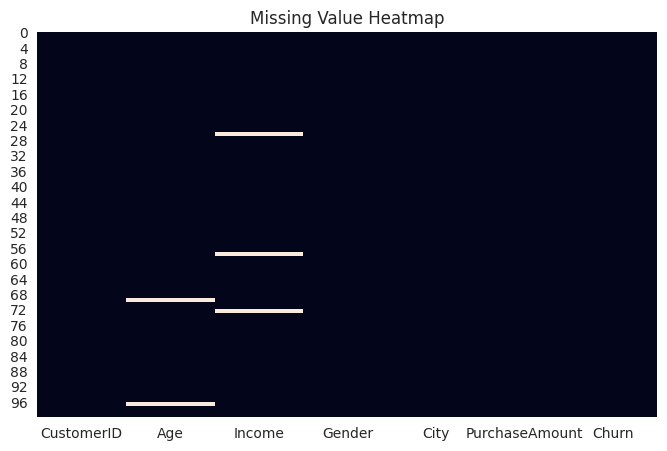

In [38]:
#Visualize Missing Values
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [39]:
#Mean Imputation
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [40]:
#Median Imputation
df["Income"] = df["Income"].fillna(df["Income"].median())

Discussion
- Why median for Income?
- Because income is usually skewed, so the median is more robust to extreme values than the mean.

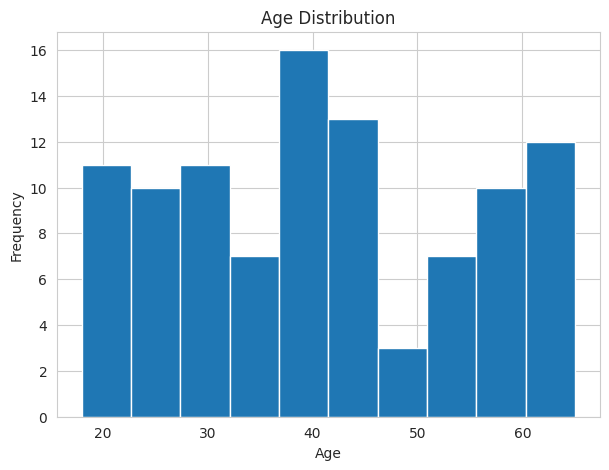

In [41]:
#Distribution
#Age Distribution
plt.figure(figsize=(7,5))
df["Age"].hist(bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Questions:
Symmetric? Skewed?

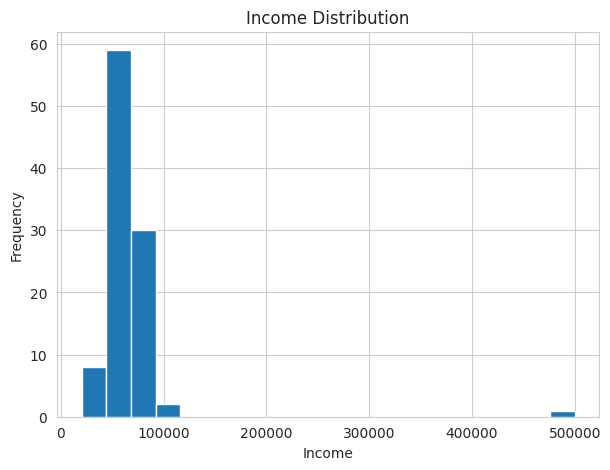

In [42]:
#Income Distribution
plt.figure(figsize=(7,5))
df["Income"].hist(bins=20)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

Observe:
- One value far away
- Potential Outlier!

### Understanding Variance
Variance measures spread.

In [43]:
df["Income"].var()

2107105906.0584846

In [44]:
#Standard Deviation
df["Income"].std()

45903.22326436875

Interpretation:
Higher standard deviation means more spread.

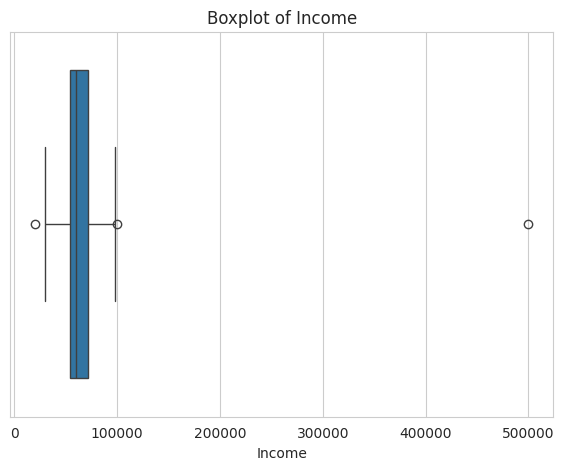

In [45]:
#Outlier Detection
#Box Plot
plt.figure(figsize=(7,5))
sns.boxplot(x=df["Income"])
plt.title("Boxplot of Income")
plt.show()

Question:
Can you identify the outlier?

In [46]:
#IQR Method
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper

(np.float64(27209.75), np.float64(98123.75))

In [47]:
#Find Outliers
outliers = df[
    (df["Income"] < lower) |
    (df["Income"] > upper)
]

outliers

,CustomerID,Age,Income,Gender,City,PurchaseAmount,Churn
20,21,47.0,100000.0,F,Bengaluru,4862,0
46,47,26.0,20172.0,F,Bengaluru,5111,0
74,75,48.0,500000.0,F,Chennai,6271,0


In [48]:
#Remove Outliers
df_clean = df[
    (df["Income"] >= lower) &
    (df["Income"] <= upper)
]

df_clean.shape

(97, 7)

#Noisy Data

Example:
Income = 500000

Domain knowledge helps decide:
- Remove
- Cap
- Keep

In [49]:
#Winsorization
df["Income"] = np.where(
    df["Income"] > upper,
    upper,
    df["Income"]
)

### Categorical Analysis

In [50]:
#Gender Counts
print(df["Gender"].value_counts())
#City Counts
print(df["City"].value_counts())

Gender
F    56
M    44
Name: count, dtype: int64
City
Chennai      30
Bengaluru    25
Mumbai       24
Delhi        21
Name: count, dtype: int64


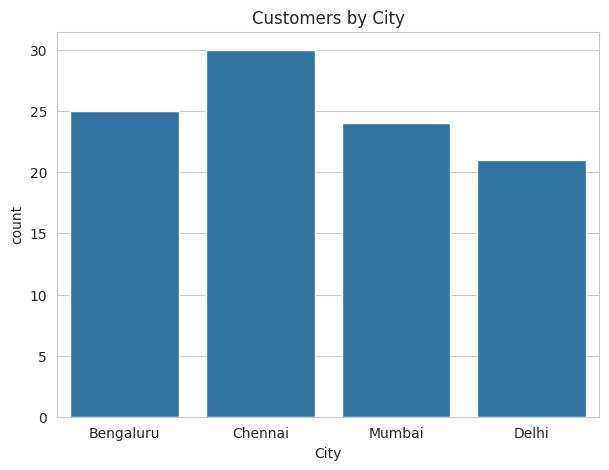

In [51]:
#Visualization
plt.figure(figsize=(7,5))
sns.countplot(x="City", data=df)
plt.title("Customers by City")
plt.show()

### Data Imbalance

In [52]:
#Check Target Distribution
df["Churn"].value_counts()

,count
Churn,
0,82
1,18


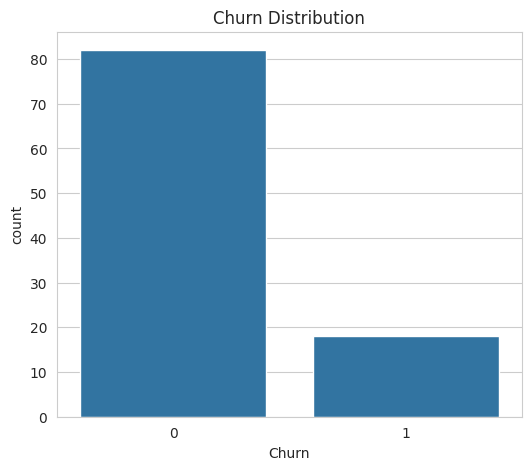

In [53]:
#Visualize
plt.figure(figsize=(6,5))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

Discussion:

Problem:
Model learns majority class

In [54]:
#Handling Imbalance
# pip install imbalanced-learn --quiet   # uncomment if not installed
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X = df[["Age", "Income", "PurchaseAmount"]]
y = df["Churn"]

X_resampled, y_resampled = smote.fit_resample(X, y)
print("Before:", y.value_counts().to_dict())
print("After: ", y_resampled.value_counts().to_dict())

Before: {0: 82, 1: 18}
After:  {0: 82, 1: 82}


In [55]:
df.corr(numeric_only=True)

,CustomerID,Age,Income,PurchaseAmount,Churn
CustomerID,1.000000,-0.006227,0.070125,0.077097,-0.075744
Age,-0.006227,1.000000,0.025855,0.079772,-0.003964
Income,0.070125,0.025855,1.000000,0.022736,0.056339
PurchaseAmount,0.077097,0.079772,0.022736,1.000000,-0.042847
Churn,-0.075744,-0.003964,0.056339,-0.042847,1.000000


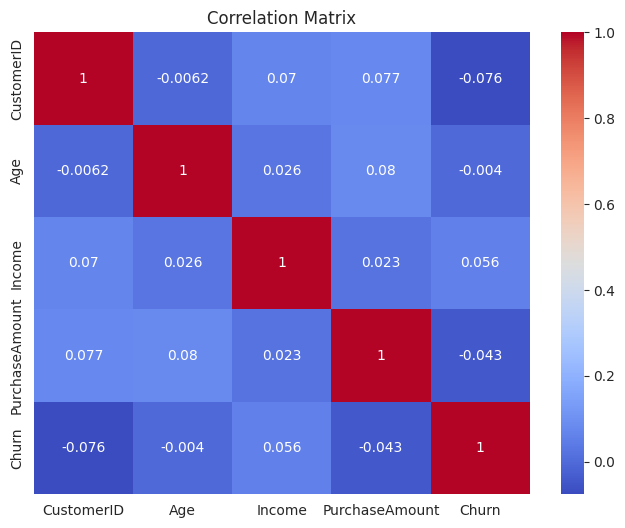

In [56]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Discussion:
- Positive correlation
- Negative correlation
- No correlation

In [57]:
#Feature Encoding
#One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["Gender", "City"])
df_encoded.head()

,CustomerID,Age,Income,PurchaseAmount,Churn,Gender_F,Gender_M,City_Bengaluru,City_Chennai,City_Delhi,City_Mumbai
0,1,56.0,68732.0,5577,0,True,False,True,False,False,False
1,2,46.0,73316.0,4481,0,False,True,False,True,False,False
2,3,32.0,73415.0,4046,0,True,False,False,True,False,False
3,4,60.0,71325.0,5474,0,True,False,False,True,False,False
4,5,25.0,56893.0,3206,0,True,False,False,False,False,True


Explain why ML models need numbers.

In [58]:
#Feature Scaling
#Before Scaling
df[["Age", "Income"]].head()

,Age,Income
0,56.0,68732.0
1,46.0,73316.0
2,32.0,73415.0
3,60.0,71325.0
4,25.0,56893.0


Different scales.

In [59]:
#Standardization
scaler = StandardScaler()

df[["Age", "Income"]] = scaler.fit_transform(
    df[["Age", "Income"]]
)

df[["Age", "Income"]].head()

,Age,Income
0,1.100251,0.483738
1,0.372198,0.811733
2,-0.647075,0.818816
3,1.391472,0.669272
4,-1.156712,-0.363368


In [60]:
#Final Clean Dataset
df.head()

,CustomerID,Age,Income,Gender,City,PurchaseAmount,Churn
0,1,1.100251,0.483738,F,Bengaluru,5577,0
1,2,0.372198,0.811733,M,Chennai,4481,0
2,3,-0.647075,0.818816,F,Chennai,4046,0
3,4,1.391472,0.669272,F,Chennai,5474,0
4,5,-1.156712,-0.363368,F,Mumbai,3206,0


Checklist:
- [x] Missing values handled
- [x] Outliers treated
- [x] Categories encoded
- [x] Features scaled
- [x] Dataset ready for ML